In [ ]:
# Install required packages
!pip install -q albumentations opencv-python-headless tensorboard


## I trained this model on Google Colab

In [ ]:
import os
import random
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image
import json

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter

import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU: Tesla T4


In [ ]:
config = {
    # Data
    'data_dir': '/content/data',  
    'image_size': [512, 512],
    'num_workers': 2,

    # Model
    'in_channels': 3,
    'out_channels': 1,
    'init_features': 64,
    'dropout': 0.2,

    # Training
    'batch_size': 8,  
    'num_epochs': 150,
    'learning_rate': 0.001,
    'weight_decay': 0.0001,
    'dice_weight': 0.7,
    'bce_weight': 0.3,
    'use_amp': True,
    'grad_clip': 1.0,

    # Scheduler
    'scheduler_type': 'cosine',
    'min_lr': 1e-6,

    # Early stopping
    'patience': 20,
    'min_delta': 0.001,

    # ISCIS normalization stats
      'mean': [0.724, 0.619, 0.567],
      'std': [0.164, 0.171, 0.192],


    # Inference
    'threshold': 0.5,

    # Reproducibility
    'seed': 42,

    'save_dir': '/content/exp2_results'
}

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config['seed'])
print("Configuration loaded!")

Configuration loaded!


In [ ]:
# ===================================================================
# Mount Google Drive and Extract ZIP Files
# ===================================================================

from google.colab import drive
import zipfile
import os
from pathlib import Path

drive.mount('/content/drive')

# Path to your data folder in Google Drive
# UPDATE THIS PATH to match your Google Drive folder location
drive_data_path = '/content/drive/MyDrive/Colab_Notebooks_Data'

print(f"Looking for data in: {drive_data_path}")
print("\nChecking for ZIP files...")

# Expected ZIP files
zip_files = {
    'train_images': 'ISBI2016_ISIC_Part1_Training_Data.zip',
    'train_masks': 'ISBI2016_ISIC_Part1_Training_GroundTruth.zip',
    'test_images': 'ISBI2016_ISIC_Part1_Test_Data.zip',
    'test_masks': 'ISBI2016_ISIC_Part1_Test_GroundTruth.zip'
}

# Check if all files exist
missing_files = []
for key, filename in zip_files.items():
    filepath = os.path.join(drive_data_path, filename)
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  ✓ {filename} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ {filename} NOT FOUND")
        missing_files.append(filename)

if missing_files:
    print(f"\n❌ Error: Missing files: {missing_files}")
    print(f"\nPlease upload these files to: {drive_data_path}")
    raise FileNotFoundError(f"Missing ZIP files: {missing_files}")

print("\n✓ All ZIP files found!")
print("\nExtracting ZIP files to /content/...")

# Create extraction directories
extraction_dirs = {
    'train_images': '/content/training_images',
    'train_masks': '/content/training_masks',
    'test_images': '/content/test_images',
    'test_masks': '/content/test_masks'
}

# Extract each ZIP file
for key, zip_filename in zip_files.items():
    zip_path = os.path.join(drive_data_path, zip_filename)
    extract_to = extraction_dirs[key]

    print(f"\nExtracting {zip_filename}...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Get list of files in zip
        file_list = zip_ref.namelist()

        # Check if files are in a subdirectory
        if file_list and '/' in file_list[0]:
            # Files are in a subdirectory, extract and move
            temp_dir = f'/content/temp_{key}'
            zip_ref.extractall(temp_dir)

            # Find the actual data directory
            subdirs = [d for d in os.listdir(temp_dir) if os.path.isdir(os.path.join(temp_dir, d))]
            if subdirs:
                actual_data_dir = os.path.join(temp_dir, subdirs[0])

                # Move to correct location
                import shutil
                if os.path.exists(extract_to):
                    shutil.rmtree(extract_to)
                shutil.move(actual_data_dir, extract_to)
                shutil.rmtree(temp_dir)
            else:
                # Files are directly in zip
                if os.path.exists(extract_to):
                    shutil.rmtree(extract_to)
                shutil.move(temp_dir, extract_to)
        else:
            # Files are directly in zip, extract to target directory
            os.makedirs(extract_to, exist_ok=True)
            zip_ref.extractall(extract_to)

    # Count extracted files
    if os.path.exists(extract_to):
        num_files = len([f for f in os.listdir(extract_to) if os.path.isfile(os.path.join(extract_to, f))])
        print(f"  ✓ Extracted {num_files} files to {extract_to}")
    else:
        print(f"  ✗ Failed to extract to {extract_to}")

print("\n" + "="*60)
print("Extraction Summary:")
print("="*60)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for data in: /content/drive/MyDrive/Colab_Notebooks_Data

Checking for ZIP files...
  ✓ ISBI2016_ISIC_Part1_Training_Data.zip (602.4 MB)
  ✓ ISBI2016_ISIC_Part1_Training_GroundTruth.zip (5.7 MB)
  ✓ ISBI2016_ISIC_Part1_Test_Data.zip (231.7 MB)
  ✓ ISBI2016_ISIC_Part1_Test_GroundTruth.zip (2.3 MB)

✓ All ZIP files found!

Extracting ZIP files to /content/...

Extracting ISBI2016_ISIC_Part1_Training_Data.zip...
  ✓ Extracted 900 files to /content/training_images

Extracting ISBI2016_ISIC_Part1_Training_GroundTruth.zip...
  ✓ Extracted 900 files to /content/training_masks

Extracting ISBI2016_ISIC_Part1_Test_Data.zip...
  ✓ Extracted 379 files to /content/test_images

Extracting ISBI2016_ISIC_Part1_Test_GroundTruth.zip...
  ✓ Extracted 379 files to /content/test_masks

Extraction Summary:


In [ ]:
def organize_isic2016_standard(base_dir='/content'):
    """
    Organize ISIC 2016 dataset into standard train/val/test splits.

    Split strategy:
      - Training data (900) → 720 train (80%) + 180 val (20%)
      - Test data (379)     → 379 test (100% - official test set)
    """

    print("\n" + "="*80)
    print("📦 STEP 2: ORGANIZING INTO TRAIN/VAL/TEST SPLITS")
    print("="*80)

    # Source directories
    train_images_src = Path(base_dir) / "training_images"
    train_masks_src = Path(base_dir) / "training_masks"
    test_images_src = Path(base_dir) / "test_images"
    test_masks_src = Path(base_dir) / "test_masks"

    data_dir = Path('/content/data')
    print(f"\n📁 Creating organized directory: {data_dir}")

    for split in ['train', 'val', 'test']:
        (data_dir / split / 'images').mkdir(parents=True, exist_ok=True)
        (data_dir / split / 'masks').mkdir(parents=True, exist_ok=True)
    print("  ✓ Directory structure created")


    print("\n" + "-"*80)
    print("PART A: Splitting Training Data (900 images)")
    print("-"*80)

    train_image_files = sorted([
        f for f in os.listdir(train_images_src) if f.endswith('.jpg')
    ])

    # Shuffle with fixed seed for reproducibility
    random.seed(42)
    random.shuffle(train_image_files)

    # Split: 720 train, 180 val
    train_files = train_image_files[:720]
    val_files = train_image_files[720:]

    print(f"\n  Split breakdown:")
    print(f"    Train: {len(train_files)} images (80%)")
    print(f"    Val:   {len(val_files)} images (20%)")

    # Copy training files
    print(f"\n📋 Copying training files...")
    for img_file in tqdm(train_files, desc="  Training"):
        img_id = img_file.replace('.jpg', '')
        mask_file = f"{img_id}_Segmentation.png"

        shutil.copy2(train_images_src / img_file, data_dir / 'train' / 'images' / img_file)
        shutil.copy2(train_masks_src / mask_file, data_dir / 'train' / 'masks' / mask_file)

    # Copy validation files
    print(f"📋 Copying validation files...")
    for img_file in tqdm(val_files, desc="  Validation"):
        img_id = img_file.replace('.jpg', '')
        mask_file = f"{img_id}_Segmentation.png"

        shutil.copy2(train_images_src / img_file, data_dir / 'val' / 'images' / img_file)
        shutil.copy2(train_masks_src / mask_file, data_dir / 'val' / 'masks' / mask_file)

   
    # PART B: Copy ALL 379 test images → test set
    print("\n" + "-"*80)
    print("PART B: Organizing Test Data (379 images)")
    print("-"*80)

    test_image_files = sorted([
        f for f in os.listdir(test_images_src) if f.endswith('.jpg')
    ])

    print(f"\n  Test: {len(test_image_files)} images (100% - official ISIC 2016 test set)")

    # Copy all test files
    print(f"\n📋 Copying test files...")
    for img_file in tqdm(test_image_files, desc="  Test"):
        img_id = img_file.replace('.jpg', '')
        mask_file = f"{img_id}_Segmentation.png"

        shutil.copy2(test_images_src / img_file, data_dir / 'test' / 'images' / img_file)
        shutil.copy2(test_masks_src / mask_file, data_dir / 'test' / 'masks' / mask_file)

    # ========================================================================
    # Summary
    # ========================================================================
    print("\n" + "="*80)
    print("✅ DATA ORGANIZATION COMPLETE!")
    print("="*80)

    print("\n📊 Final Dataset Split:")
    print(f"  {'Split':<15} {'Samples':>8} {'Source':>25} {'Purpose'}")
    print(f"  {'-'*15} {'-'*8} {'-'*25} {'-'*35}")
    print(f"  {'Train':<15} {len(train_files):>8} {'ISIC 2016 Training':>25} Model training")
    print(f"  {'Validation':<15} {len(val_files):>8} {'ISIC 2016 Training':>25} Hyperparameter tuning")
    print(f"  {'Test':<15} {len(test_image_files):>8} {'ISIC 2016 Test':>25} Final evaluation (official)")
    print(f"  {'-'*15} {'-'*8} {'-'*25} {'-'*35}")
    print(f"  {'TOTAL':<15} {len(train_files)+len(val_files)+len(test_image_files):>8}")

    print(f"\n📁 Organized Data Location: {data_dir}")

    print("\n✅ Key Benefits:")
    print("  • Follows standard ISIC 2016 benchmark protocol")
    print("  • Results comparable with published papers")
    print("  • Larger validation set (180 vs 90) for stable metrics")
    print("  • Official 379-image test set for final evaluation")

    print("\n🎯 Next Steps:")
    print("  1. Train model on 720 images")
    print("  2. Monitor validation performance (180 images)")
    print("  3. Final evaluation on test set (379 images)")
    print("  4. Apply TTA for +1.5-2.0% Dice boost")

    print("="*80)

    return {
        'train': len(train_files),
        'val': len(val_files),
        'test': len(test_image_files),
        'data_dir': str(data_dir)
    }


# Execute organization
stats = organize_isic2016_standard()

# Verify the organization
print("\n🔍 Final Verification:")
data_dir = Path('/content/data')

for split in ['train', 'val', 'test']:
    img_count = len(list((data_dir / split / 'images').glob('*.jpg')))
    mask_count = len(list((data_dir / split / 'masks').glob('*.png')))
    match = "✅" if img_count == mask_count else "❌"
    print(f"  {split.capitalize():>10}: {img_count:3d} images, {mask_count:3d} masks {match}")

print("\n" + "="*80)
print("🚀 READY FOR TRAINING!")
print("="*80)
print(f"\nDataset organized at: /content/data/")
print(f"  • Train:      {stats['train']} samples")
print(f"  • Validation: {stats['val']} samples")
print(f"  • Test:       {stats['test']} samples (official ISIC 2016 test set)")
print("\n✅ Proceed to next cell to start training!")



📦 STEP 2: ORGANIZING INTO TRAIN/VAL/TEST SPLITS

📁 Creating organized directory: /content/data
  ✓ Directory structure created

--------------------------------------------------------------------------------
PART A: Splitting Training Data (900 images)
--------------------------------------------------------------------------------

  Split breakdown:
    Train: 720 images (80%)
    Val:   180 images (20%)

📋 Copying training files...


  Training:   0%|          | 0/720 [00:00<?, ?it/s]

📋 Copying validation files...


  Validation:   0%|          | 0/180 [00:00<?, ?it/s]


--------------------------------------------------------------------------------
PART B: Organizing Test Data (379 images)
--------------------------------------------------------------------------------

  Test: 379 images (100% - official ISIC 2016 test set)

📋 Copying test files...


  Test:   0%|          | 0/379 [00:00<?, ?it/s]


✅ DATA ORGANIZATION COMPLETE!

📊 Final Dataset Split:
  Split            Samples                    Source Purpose
  --------------- -------- ------------------------- -----------------------------------
  Train                720        ISIC 2016 Training Model training
  Validation           180        ISIC 2016 Training Hyperparameter tuning
  Test                 379            ISIC 2016 Test Final evaluation (official)
  --------------- -------- ------------------------- -----------------------------------
  TOTAL               1279

📁 Organized Data Location: /content/data

✅ Key Benefits:
  • Follows standard ISIC 2016 benchmark protocol
  • Results comparable with published papers
  • Larger validation set (180 vs 90) for stable metrics
  • Official 379-image test set for final evaluation

🎯 Next Steps:
  1. Train model on 720 images
  2. Monitor validation performance (180 images)
  3. Final evaluation on test set (379 images)
  4. Apply TTA for +1.5-2.0% Dice boost

🔍 Final 

In [ ]:
class DoubleConv(nn.Module):
    """Double Convolution Block"""
    def __init__(self, in_channels, out_channels, mid_channels=None, dropout=0.0):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downsampling Block"""
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, dropout=dropout)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upsampling Block"""
    def __init__(self, in_channels, out_channels, bilinear=True, dropout=0.0):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            # Reduce channels BEFORE concatenation with 1x1 conv
            self.reduce_channels = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
            self.conv = DoubleConv(in_channels, out_channels, dropout=dropout)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels, dropout=dropout)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # If using bilinear, reduce channels after upsampling
        if hasattr(self, 'reduce_channels'):
            x1 = self.reduce_channels(x1)

        # Handle size mismatch
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        # Concatenate skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """UNet Architecture"""
    def __init__(self, in_channels=3, out_channels=1, init_features=64, dropout=0.0):
        super(UNet, self).__init__()

        # Encoder
        self.inc = DoubleConv(in_channels, init_features, dropout=dropout)
        self.down1 = Down(init_features, init_features * 2, dropout=dropout)
        self.down2 = Down(init_features * 2, init_features * 4, dropout=dropout)
        self.down3 = Down(init_features * 4, init_features * 8, dropout=dropout)
        self.down4 = Down(init_features * 8, init_features * 16, dropout=dropout)
        self.down5 = Down(init_features * 16, init_features * 36, dropout=dropout)

        # Decoder
        self.up1 = Up(init_features * 16, init_features * 8, True, dropout=dropout)
        self.up2 = Up(init_features * 8, init_features * 4, True, dropout=dropout)
        self.up3 = Up(init_features * 4, init_features * 2, True, dropout=dropout)
        self.up4 = Up(init_features * 2, init_features, True, dropout=dropout)

        # Output
        self.outc = nn.Conv2d(init_features, out_channels, kernel_size=1)

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x6 = self.down5(x5)

        # Decoder
        x = self.up1(x6, x5)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.outc(x)
        return logits

# Test model
model = UNet(in_channels=3, out_channels=1, init_features=64, dropout=0.2)
total_params = sum(p.numel() for p in model.parameters())
print(f"UNet created with {total_params:,} parameters")

# Test forward pass
x = torch.randn(1, 3, 512, 512)
y = model(x)
print(f"Input: {x.shape} → Output: {y.shape}")
print("✓ Model working!")

UNet created with 28,948,673 parameters
Input: torch.Size([1, 3, 512, 512]) → Output: torch.Size([1, 1, 512, 512])
✓ Model working!


In [ ]:
def compute_dataset_statistics(data_dir='/content/data', num_samples=None):
    """
    Compute mean and std statistics for the dataset.

    Args:
        data_dir: Path to organized data directory
        num_samples: Limit number of samples to process (None = use all)

    Returns:
        mean, std: Lists of [R, G, B] values
    """
    from torch.utils.data import DataLoader
    import torchvision.transforms as T

    print("Computing dataset statistics...")
    print("This may take 2-3 minutes...\n")

    # Create a simple dataset without normalization
    class SimpleImageDataset(Dataset):
        def __init__(self, images_dir):
            self.images_dir = Path(images_dir)
            self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])
            if num_samples:
                self.image_files = self.image_files[:num_samples]

        def __len__(self):
            return len(self.image_files)

        def __getitem__(self, idx):
            img_file = self.image_files[idx]
            image = Image.open(self.images_dir / img_file).convert('RGB')
            # Resize to consistent size and convert to tensor [0, 1]
            transform = T.Compose([
                T.Resize((512, 512)),
                T.ToTensor()  # Converts to [0, 1]
            ])
            return transform(image)

    # Load training images only (use train set for statistics)
    dataset = SimpleImageDataset(os.path.join(data_dir, 'train', 'images'))
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

    print(f"Processing {len(dataset)} training images...")

    # Compute mean and std
    channels_sum = torch.zeros(3)
    channels_squared_sum = torch.zeros(3)
    num_batches = 0

    for images in tqdm(loader, desc="Computing statistics"):
        # images shape: (batch, 3, H, W)
        channels_sum += images.mean(dim=[0, 2, 3])  # Mean over batch, height, width
        channels_squared_sum += (images ** 2).mean(dim=[0, 2, 3])
        num_batches += 1

    # Calculate mean and std
    mean = channels_sum / num_batches
    std = torch.sqrt(channels_squared_sum / num_batches - mean ** 2)

    mean = mean.tolist()
    std = std.tolist()

    # Print results
    print("\n" + "="*60)
    print("Dataset Statistics Comparison")
    print("="*60)
    print(f"\n📊 ISIC Dataset Statistics (from {len(dataset)} images):")
    print(f"   Mean: {mean}")
    print(f"   Std:  {std}")
    print(f"\n📊 ImageNet Statistics (standard):")
    print(f"   Mean: [0.485, 0.456, 0.406]")
    print(f"   Std:  [0.229, 0.224, 0.225]")

    print(f"\n📈 Difference Analysis:")
    print(f"   Mean difference: [R: {mean[0]-0.485:+.3f}, G: {mean[1]-0.456:+.3f}, B: {mean[2]-0.406:+.3f}]")
    print(f"   Std difference:  [R: {std[0]-0.229:+.3f}, G: {std[1]-0.224:+.3f}, B: {std[2]-0.225:+.3f}]")

    print(f"\n💡 Interpretation:")
    if mean[0] > 0.6:
        print(f"   - Images are BRIGHTER than ImageNet (skin lesions are light)")
    else:
        print(f"   - Images have similar brightness to ImageNet")

    if std[0] < 0.2:
        print(f"   - Images have LESS variation than ImageNet (more consistent)")
    else:
        print(f"   - Images have similar variation to ImageNet")

    print(f"\n🔧 To use these statistics instead of ImageNet:")
    print(f"   Update config:")
    print(f"   config['mean'] = {[round(x, 3) for x in mean]}")
    print(f"   config['std'] = {[round(x, 3) for x in std]}")
    print("="*60)

    return mean, std


# Run the computation (optional - you can skip this)
# Uncomment the line below to compute statistics:

dataset_mean, dataset_std = compute_dataset_statistics('/content/data', num_samples=None)

print("✓ Statistics computation function ready!")
print("  Uncomment the last line to run the computation.")
print("  (Takes ~2-3 minutes for all 720 training images)")

Computing dataset statistics...
This may take 2-3 minutes...

Processing 720 training images...


Computing statistics:   0%|          | 0/23 [00:00<?, ?it/s]


Dataset Statistics Comparison

📊 ISIC Dataset Statistics (from 720 images):
   Mean: [0.7243376970291138, 0.6191481947898865, 0.5674951672554016]
   Std:  [0.16426309943199158, 0.17122527956962585, 0.19232463836669922]

📊 ImageNet Statistics (standard):
   Mean: [0.485, 0.456, 0.406]
   Std:  [0.229, 0.224, 0.225]

📈 Difference Analysis:
   Mean difference: [R: +0.239, G: +0.163, B: +0.161]
   Std difference:  [R: -0.065, G: -0.053, B: -0.033]

💡 Interpretation:
   - Images are BRIGHTER than ImageNet (skin lesions are light)
   - Images have LESS variation than ImageNet (more consistent)

🔧 To use these statistics instead of ImageNet:
   Update config:
   config['mean'] = [0.724, 0.619, 0.567]
   config['std'] = [0.164, 0.171, 0.192]
✓ Statistics computation function ready!
  Uncomment the last line to run the computation.
  (Takes ~2-3 minutes for all 720 training images)


In [ ]:
class SegmentationDataset(Dataset):
    """Dataset for image segmentation"""
    def __init__(self, images_dir, masks_dir, image_size=(512, 512),
                 transform=None, normalize=None):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.transform = transform
        self.normalize = normalize

        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image
        img_file = self.image_files[idx]
        image = Image.open(self.images_dir / img_file).convert('RGB')
        image = np.array(image)

        # Load mask
        img_id = img_file.replace('.jpg', '')
        mask_file = f"{img_id}_Segmentation.png"
        mask = Image.open(self.masks_dir / mask_file).convert('L')
        mask = np.array(mask)
        mask = (mask > 127).astype(np.float32)

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            resize = A.Resize(height=self.image_size[0], width=self.image_size[1])
            augmented = resize(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Normalize and convert to tensor
        if self.normalize:
            normalize_transform = A.Compose([
                A.Normalize(mean=self.normalize['mean'], std=self.normalize['std']),
                ToTensorV2()
            ])
            augmented = normalize_transform(image=image, mask=mask)
            image = augmented['image']
            mask = torch.from_numpy(mask).unsqueeze(0)
        else:
            to_tensor = ToTensorV2()
            augmented = to_tensor(image=image, mask=mask)
            image = augmented['image'].float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0)

        return {'image': image, 'mask': mask, 'filename': img_file}


def get_train_transform(config):
    """Get training augmentation pipeline"""
    return A.Compose([
        A.Resize(height=config['image_size'][0], width=config['image_size'][1]),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=30, p=0.5),
        A.ElasticTransform(alpha=1.0, sigma=50, p=0.3),
        A.GridDistortion(p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.CLAHE(clip_limit=2.0, p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    ])


def get_val_transform(config):
    """Get validation transform (resize only)"""
    return A.Compose([
        A.Resize(height=config['image_size'][0], width=config['image_size'][1])
    ])


# Create dataloaders
def get_dataloaders(config):
    normalize = {'mean': config['mean'], 'std': config['std']}

    train_dataset = SegmentationDataset(
        images_dir=os.path.join(config['data_dir'], 'train', 'images'),
        masks_dir=os.path.join(config['data_dir'], 'train', 'masks'),
        image_size=config['image_size'],
        transform=get_train_transform(config),
        normalize=normalize
    )

    val_dataset = SegmentationDataset(
        images_dir=os.path.join(config['data_dir'], 'val', 'images'),
        masks_dir=os.path.join(config['data_dir'], 'val', 'masks'),
        image_size=config['image_size'],
        transform=get_val_transform(config),
        normalize=normalize
    )

    test_dataset = SegmentationDataset(
        images_dir=os.path.join(config['data_dir'], 'test', 'images'),
        masks_dir=os.path.join(config['data_dir'], 'test', 'masks'),
        image_size=config['image_size'],
        transform=get_val_transform(config),
        normalize=normalize
    )

    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'], shuffle=True,
        num_workers=config['num_workers'], pin_memory=True, drop_last=True
    )

    val_loader = DataLoader(
        val_dataset, batch_size=config['batch_size'], shuffle=False,
        num_workers=config['num_workers'], pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset, batch_size=config['batch_size'], shuffle=False,
        num_workers=config['num_workers'], pin_memory=True
    )

    print(f"Dataloaders created:")
    print(f"  Train: {len(train_dataset)} samples, {len(train_loader)} batches")
    print(f"  Val: {len(val_dataset)} samples, {len(val_loader)} batches")
    print(f"  Test: {len(test_dataset)} samples, {len(test_loader)} batches")

    return train_loader, val_loader, test_loader

# Create dataloaders
train_loader, val_loader, test_loader = get_dataloaders(config)

Dataloaders created:
  Train: 720 samples, 90 batches
  Val: 180 samples, 23 batches
  Test: 379 samples, 48 batches


/tmp/ipython-input-1845765223.py:71: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),


In [ ]:
class DiceLoss(nn.Module):
    """Dice Loss"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = torch.sigmoid(predictions)
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (predictions.sum() + targets.sum() + self.smooth)

        return 1 - dice


class CombinedLoss(nn.Module):
    """Combined Dice + BCE Loss"""
    def __init__(self, dice_weight=0.7, bce_weight=0.3):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, predictions, targets):
        dice = self.dice_loss(predictions, targets)
        bce = self.bce_loss(predictions, targets)
        return self.dice_weight * dice + self.bce_weight * bce


class SegmentationMetrics:
    """Calculate segmentation metrics"""
    def __init__(self, threshold=0.5, smooth=1e-6):
        self.threshold = threshold
        self.smooth = smooth
        self.reset()

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.tn = 0
        self.fn = 0
        self.total_dice = 0
        self.total_iou = 0
        self.n_samples = 0

    def update(self, predictions, targets):
        if predictions.max() > 1.0:
            predictions = torch.sigmoid(predictions)

        predictions = (predictions > self.threshold).float()
        targets = (targets > self.threshold).float()

        pred_flat = predictions.view(-1)
        target_flat = targets.view(-1)

        self.tp += ((pred_flat == 1) & (target_flat == 1)).sum().item()
        self.fp += ((pred_flat == 1) & (target_flat == 0)).sum().item()
        self.tn += ((pred_flat == 0) & (target_flat == 0)).sum().item()
        self.fn += ((pred_flat == 0) & (target_flat == 1)).sum().item()

        # Dice and IoU
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        union = pred_flat.sum() + target_flat.sum() - intersection
        iou = (intersection + self.smooth) / (union + self.smooth)

        self.total_dice += dice.item() * predictions.size(0)
        self.total_iou += iou.item() * predictions.size(0)
        self.n_samples += predictions.size(0)

    def get_metrics(self):
        total = self.tp + self.tn + self.fp + self.fn

        return {
            'dice_coefficient': self.total_dice / self.n_samples if self.n_samples > 0 else 0.0,
            'iou': self.total_iou / self.n_samples if self.n_samples > 0 else 0.0,
            'pixel_accuracy': (self.tp + self.tn) / total if total > 0 else 0.0,
            'precision': self.tp / (self.tp + self.fp) if (self.tp + self.fp) > 0 else 0.0,
            'recall': self.tp / (self.tp + self.fn) if (self.tp + self.fn) > 0 else 0.0,
        }

print("Loss functions and metrics defined!")

Loss functions and metrics defined!


In [ ]:
# Initialize model, loss, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = UNet(
    in_channels=config['in_channels'],
    out_channels=config['out_channels'],
    init_features=config['init_features'],
    dropout=config['dropout']
).to(device)

criterion = CombinedLoss(
    dice_weight=config['dice_weight'],
    bce_weight=config['bce_weight']
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config['num_epochs'],
    eta_min=config['min_lr']
)

scaler = GradScaler() if config['use_amp'] else None

# TensorBoard
%load_ext tensorboard
writer = SummaryWriter('/content/runs')

print("Training setup complete!")

Using device: cuda
Training setup complete!


/tmp/ipython-input-2365888756.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if config['use_amp'] else None


In [ ]:
# Training function
def train_epoch(model, loader, criterion, optimizer, scaler, device, config):
    model.train()
    metrics = SegmentationMetrics()
    epoch_loss = 0.0

    pbar = tqdm(loader, desc="Training")
    for batch in pbar:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        optimizer.zero_grad()

        if config['use_amp']:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)

            scaler.scale(loss).backward()

            if config['grad_clip'] > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])

            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()

            if config['grad_clip'] > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])

            optimizer.step()

        epoch_loss += loss.item()
        metrics.update(outputs.detach(), masks)
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(loader)
    metrics_dict = metrics.get_metrics()

    return avg_loss, metrics_dict


@torch.no_grad()
def validate(model, loader, criterion, device, config):
    model.eval()
    metrics = SegmentationMetrics()
    epoch_loss = 0.0

    pbar = tqdm(loader, desc="Validation")
    for batch in pbar:
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)

        if config['use_amp']:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)

        epoch_loss += loss.item()
        metrics.update(outputs, masks)
        pbar.set_postfix({'loss': loss.item()})

    avg_loss = epoch_loss / len(loader)
    metrics_dict = metrics.get_metrics()

    return avg_loss, metrics_dict

print("Training functions ready!")

Training functions ready!


In [ ]:
# Main training loop
best_val_loss = float('inf')
patience_counter = 0

print("Starting training...")
print("="*60)

for epoch in range(config['num_epochs']):
    print(f"\nEpoch {epoch+1}/{config['num_epochs']}")

    # Train
    train_loss, train_metrics = train_epoch(
        model, train_loader, criterion, optimizer, scaler, device, config
    )

    # Validate
    val_loss, val_metrics = validate(
        model, val_loader, criterion, device, config
    )

    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Log to TensorBoard
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Loss/val', val_loss, epoch)
    writer.add_scalar('Dice/train', train_metrics['dice_coefficient'], epoch)
    writer.add_scalar('Dice/val', val_metrics['dice_coefficient'], epoch)
    writer.add_scalar('IoU/train', train_metrics['iou'], epoch)
    writer.add_scalar('IoU/val', val_metrics['iou'], epoch)
    writer.add_scalar('LR', current_lr, epoch)

    # Print metrics
    print(f"LR: {current_lr:.6f}")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train Dice: {train_metrics['dice_coefficient']:.4f} | Val Dice: {val_metrics['dice_coefficient']:.4f}")
    print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'metrics': val_metrics,
        }, '/content/best_model_150.pth')
        print(f"✓ Saved best model (val_loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= config['patience']:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print("\n" + "="*60)
print("Training complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
writer.close()

from google.colab import drive
import shutil
import os



drive.mount('/content/drive')

# Create folder
drive_folder = "/content/drive/My Drive/ISIC_UNet_Project/models"
os.makedirs(drive_folder, exist_ok=True)

# Copy model with descriptive name
checkpoint = torch.load('/content/best_model.pth')
val_dice = checkpoint['metrics']['dice_coefficient']
epoch = checkpoint['epoch']

filename = f"best_model_epoch{epoch+1}_dice{val_dice*100:.2f}.pth"
shutil.copy('/content/best_model.pth', f"{drive_folder}/{filename}")

print(f"✅ Model saved!")
print(f"📁 {drive_folder}/{filename}")
print(f"📊 Dice: {val_dice*100:.2f}% | Epoch: {epoch+1}")

# Check if file exists in Drive
drive_path = "/content/drive/My Drive/ISIC_UNet_Project/models"
files = os.listdir(drive_path)

print(f"📁 Models in Drive:")
for f in files:
    size_mb = os.path.getsize(f"{drive_path}/{f}") / (1024**2)
    print(f"  • {f} ({size_mb:.1f} MB)")


Starting training...

Epoch 1/150


Training:   0%|          | 0/90 [00:00<?, ?it/s]

/tmp/ipython-input-696642421.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validation:   0%|          | 0/23 [00:00<?, ?it/s]

/tmp/ipython-input-696642421.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

LR: 0.000001
Train Loss: 0.1947 | Val Loss: 0.1638
Train Dice: 0.8479 | Val Dice: 0.8737
Train IoU: 0.7410 | Val IoU: 0.7799

Epoch 150/150


Training:   0%|          | 0/90 [00:00<?, ?it/s]

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

LR: 0.000001
Train Loss: 0.1936 | Val Loss: 0.1642
Train Dice: 0.8486 | Val Dice: 0.8736
Train IoU: 0.7406 | Val IoU: 0.7796

Training complete!
Best validation loss: 0.1596
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.pth'

In [ ]:
%tensorboard --logdir /content/runs


In [13]:
from google.colab import drive
import shutil
import os



drive.mount('/content/drive')

# Create folder
drive_folder = "/content/drive/My Drive/ISIC_UNet_Project/models"
os.makedirs(drive_folder, exist_ok=True)

# Copy model with descriptive name
checkpoint = torch.load('/content/best_model.pth')
val_dice = checkpoint['metrics']['dice_coefficient']
epoch = checkpoint['epoch']

filename = f"best_model_epoch{epoch+1}_dice{val_dice*100:.2f}.pth"
shutil.copy('/content/best_model.pth', f"{drive_folder}/{filename}")

print(f"✅ Model saved!")
print(f"📁 {drive_folder}/{filename}")
print(f"📊 Dice: {val_dice*100:.2f}% | Epoch: {epoch+1}")

# Check if file exists in Drive
drive_path = "/content/drive/My Drive/ISIC_UNet_Project/models"
files = os.listdir(drive_path)

print(f"📁 Models in Drive:")
for f in files:
    size_mb = os.path.getsize(f"{drive_path}/{f}") / (1024**2)
    print(f"  • {f} ({size_mb:.1f} MB)")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.pth'

In [16]:
# Copy model with descriptive name
drive.mount('/content/drive')

checkpoint = torch.load('/content/best_model_150.pth')
val_dice = checkpoint['metrics']['dice_coefficient']
epoch = checkpoint['epoch']

filename = f"best_model_epoch{epoch+1}_dice{val_dice*100:.2f}.pth"
shutil.copy('/content/best_model_150.pth', f"{drive_folder}/{filename}")

print(f"✅ Model saved!")
print(f"📁 {drive_folder}/{filename}")
print(f"📊 Dice: {val_dice*100:.2f}% | Epoch: {epoch+1}")

# Check if file exists in Drive
drive_path = "/content/drive/My Drive/ISIC_UNet_Project/models"
files = os.listdir(drive_path)

print(f"📁 Models in Drive:")
for f in files:
    size_mb = os.path.getsize(f"{drive_path}/{f}") / (1024**2)
    print(f"  • {f} ({size_mb:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved!
📁 /content/drive/My Drive/ISIC_UNet_Project/models/best_model_epoch141_dice87.68.pth
📊 Dice: 87.68% | Epoch: 141
📁 Models in Drive:
  • best_model_epoch141_dice87.68.pth (331.4 MB)


In [17]:
# Load best model
checkpoint = torch.load('/content/best_model_150.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Validation loss: {checkpoint['val_loss']:.4f}")
print(f"Validation Dice: {checkpoint['metrics']['dice_coefficient']:.4f}")

Loaded best model from epoch 141
Validation loss: 0.1596
Validation Dice: 0.8768


In [18]:
# Evaluate on test set
test_loss, test_metrics = validate(model, test_loader, criterion, device, config)

print("\nTest Set Results:")
print("="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Dice Coefficient: {test_metrics['dice_coefficient']:.4f}")
print(f"IoU (Jaccard): {test_metrics['iou']:.4f}")
print(f"Pixel Accuracy: {test_metrics['pixel_accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print("="*60)

Validation:   0%|          | 0/48 [00:00<?, ?it/s]

/tmp/ipython-input-696642421.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Test Set Results:
Test Loss: 0.1733
Dice Coefficient: 0.8600
IoU (Jaccard): 0.7652
Pixel Accuracy: 0.9291
Precision: 0.8782
Recall: 0.8688


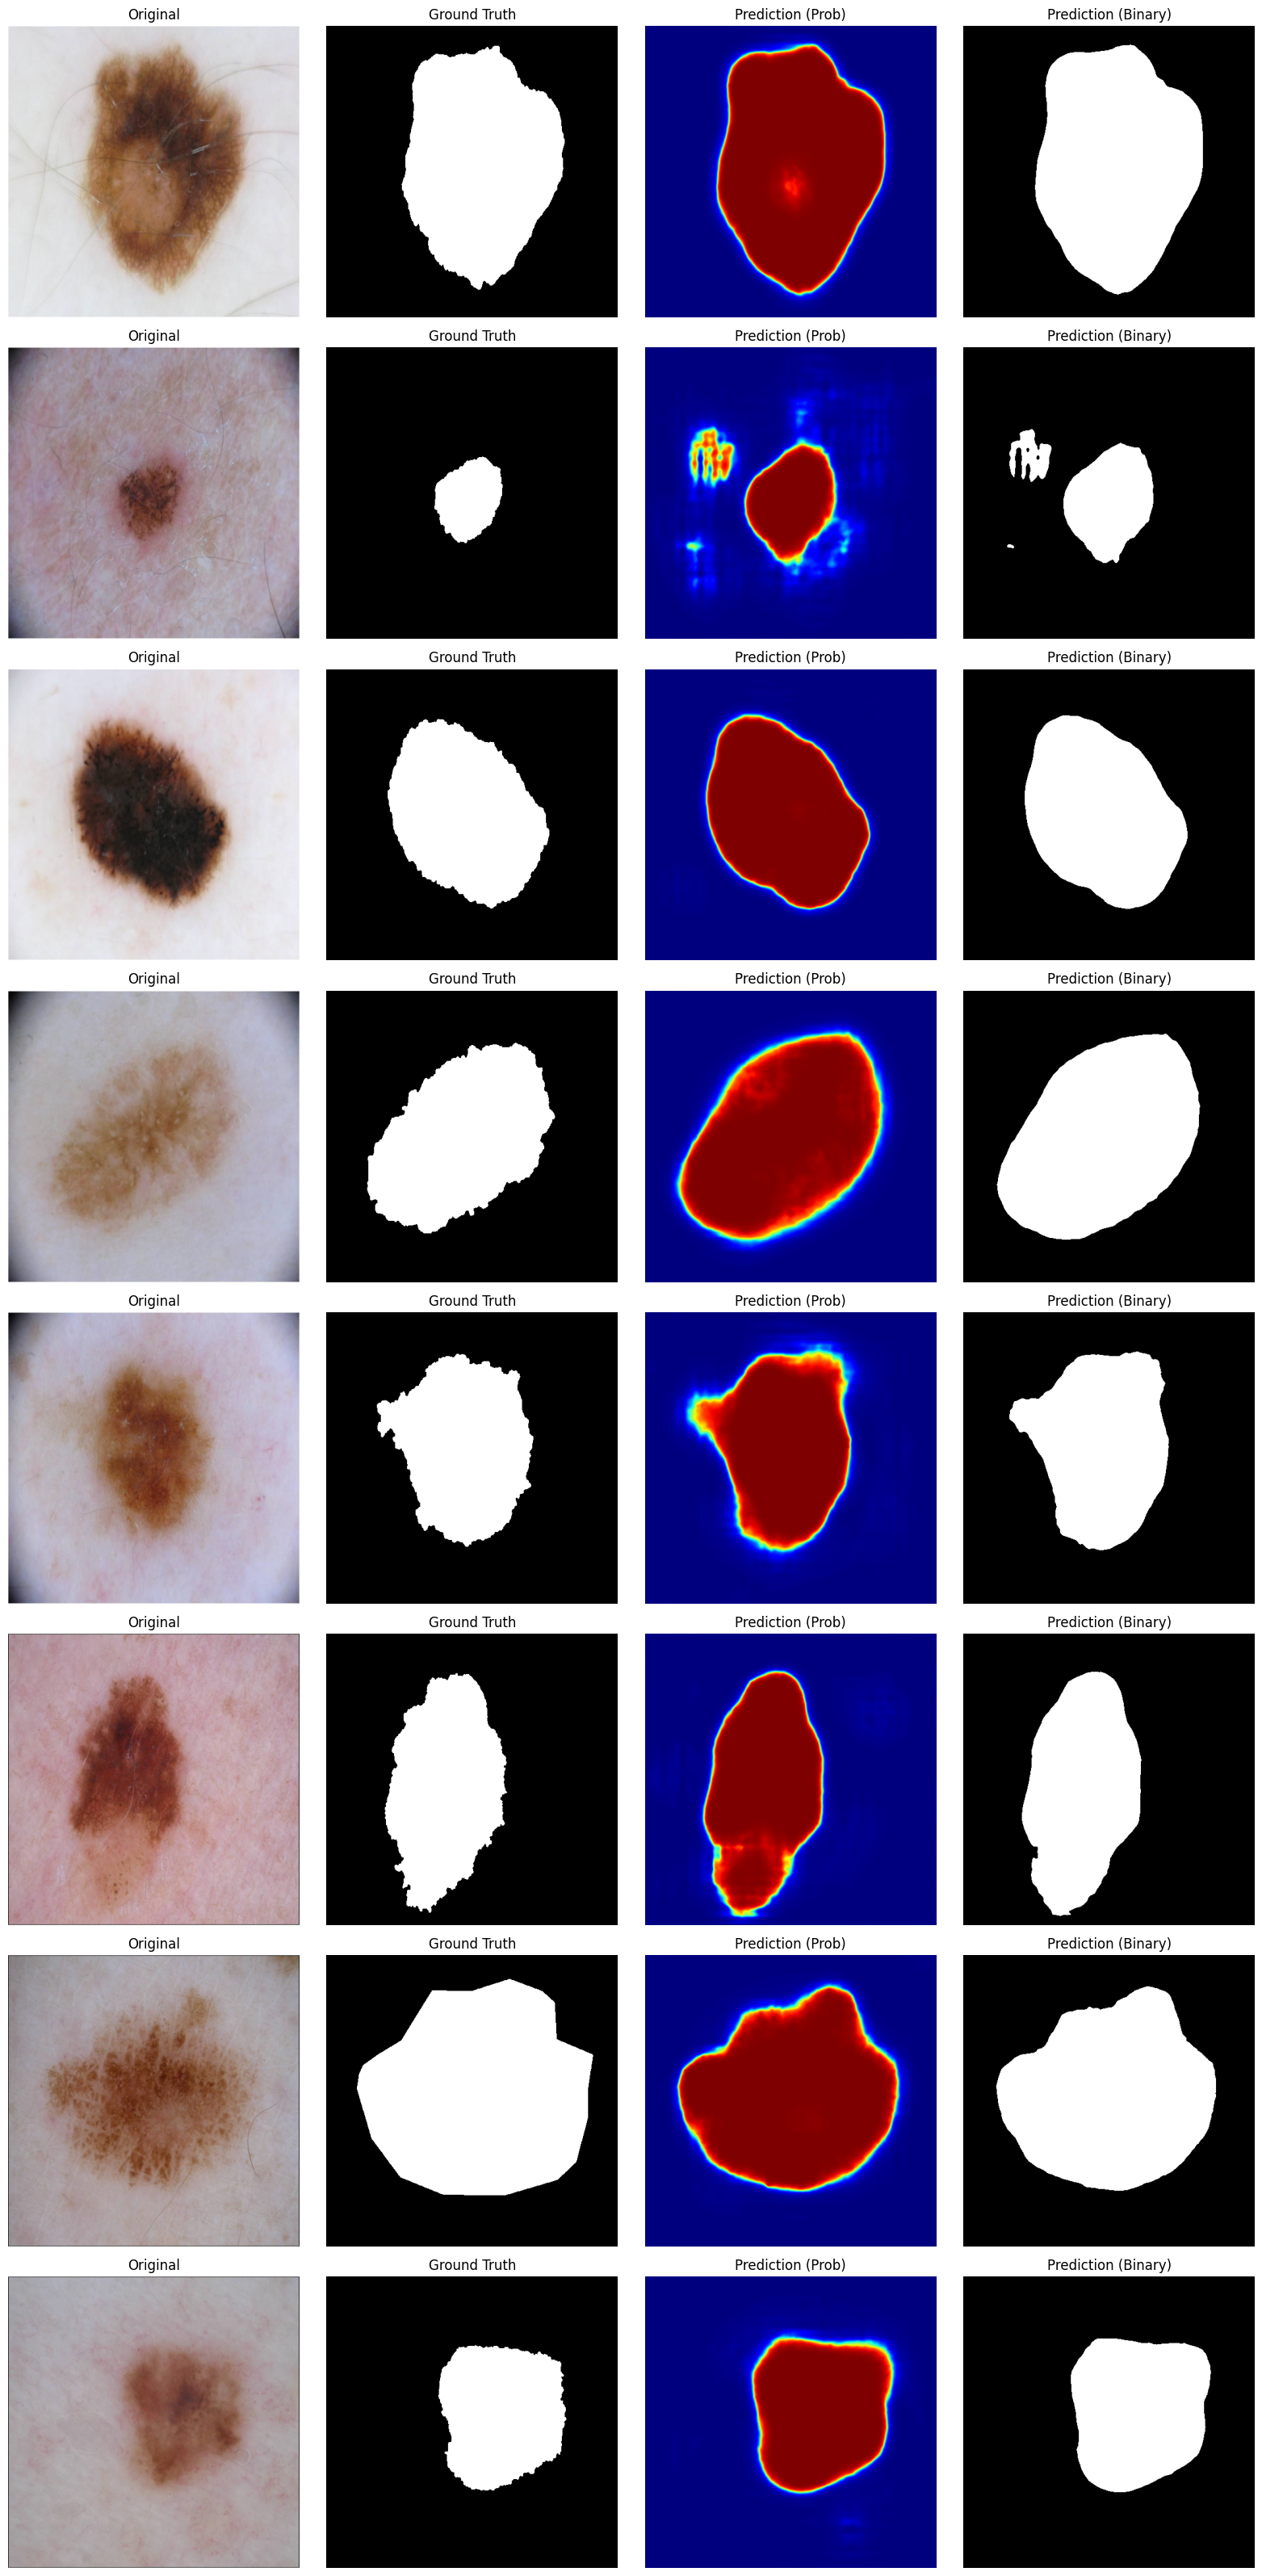

In [21]:
# Visualize predictions
@torch.no_grad()
def visualize_predictions(model, loader, device, num_samples=5):
    model.eval()

    # Get a batch
    batch = next(iter(loader))
    images = batch['image'][:num_samples].to(device)
    masks = batch['mask'][:num_samples]

    # Predict
    outputs = model(images)
    preds = torch.sigmoid(outputs).cpu()

    # Denormalize images
    mean = torch.tensor(config['mean']).view(3, 1, 1)
    std = torch.tensor(config['std']).view(3, 1, 1)
    images = images.cpu() * std + mean
    images = torch.clamp(images, 0, 1)

    # Plot
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples*4))

    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(images[i].permute(1, 2, 0))
        axes[i, 0].set_title('Original')
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(masks[i].squeeze(), cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')

        # Prediction (probability)
        axes[i, 2].imshow(preds[i].squeeze(), cmap='jet', vmin=0, vmax=1)
        axes[i, 2].set_title('Prediction (Prob)')
        axes[i, 2].axis('off')

        # Prediction (binary)
        pred_binary = (preds[i].squeeze() > config['threshold']).float()
        axes[i, 3].imshow(pred_binary, cmap='gray')
        axes[i, 3].set_title('Prediction (Binary)')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, device, num_samples=8)

In [22]:
@torch.no_grad()
def predict_with_tta(model, images, device):
    """
    Apply 8-way Test-Time Augmentation

    Transformations:
    1. Original
    2. Horizontal flip
    3. Vertical flip
    4. H+V flip
    5. Rotate 90°
    6. Rotate 180°
    7. Rotate 270°
    8. Transpose
    """
    model.eval()
    predictions = []

    # 1. Original
    predictions.append(model(images))

    # 2. Horizontal flip
    flipped = torch.flip(images, dims=[3])
    pred = model(flipped)
    predictions.append(torch.flip(pred, dims=[3]))

    # 3. Vertical flip
    flipped = torch.flip(images, dims=[2])
    pred = model(flipped)
    predictions.append(torch.flip(pred, dims=[2]))

    # 4. Both flips
    flipped = torch.flip(images, dims=[2, 3])
    pred = model(flipped)
    predictions.append(torch.flip(pred, dims=[2, 3]))

    # 5. Rotate 90°
    rotated = torch.rot90(images, k=1, dims=[2, 3])
    pred = model(rotated)
    predictions.append(torch.rot90(pred, k=-1, dims=[2, 3]))

    # 6. Rotate 180°
    rotated = torch.rot90(images, k=2, dims=[2, 3])
    pred = model(rotated)
    predictions.append(torch.rot90(pred, k=-2, dims=[2, 3]))

    # 7. Rotate 270°
    rotated = torch.rot90(images, k=3, dims=[2, 3])
    pred = model(rotated)
    predictions.append(torch.rot90(pred, k=-3, dims=[2, 3]))

    # 8. Transpose
    transposed = images.transpose(2, 3)
    pred = model(transposed)
    predictions.append(pred.transpose(2, 3))

    # Average all predictions
    return torch.stack(predictions).mean(dim=0)


@torch.no_grad()
def evaluate_with_tta(model, loader, criterion, device, config, use_tta=True):
    """Evaluate with or without TTA"""
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_samples = 0

    desc = "TTA (8x)" if use_tta else "Standard"
    for batch in tqdm(loader, desc=desc):
        images = batch['image'].to(device)
        masks = batch['mask'].to(device)
        batch_size = images.size(0)

        # Predict
        if use_tta:
            outputs = predict_with_tta(model, images, device)
        else:
            outputs = model(images)

        # Loss
        loss = criterion(outputs, masks)
        total_loss += loss.item() * batch_size

        # Dice
        preds = torch.sigmoid(outputs)
        preds_binary = (preds > config['threshold']).float()
        masks_binary = (masks > config['threshold']).float()

        intersection = (preds_binary * masks_binary).sum(dim=[1,2,3])
        dice = (2. * intersection + 1e-6) / (
            preds_binary.sum(dim=[1,2,3]) + masks_binary.sum(dim=[1,2,3]) + 1e-6
        )
        total_dice += dice.sum().item()

        # IoU
        union = preds_binary.sum(dim=[1,2,3]) + masks_binary.sum(dim=[1,2,3]) - intersection
        iou = (intersection + 1e-6) / (union + 1e-6)
        total_iou += iou.sum().item()

        n_samples += batch_size

    return total_loss / n_samples, total_dice / n_samples, total_iou / n_samples


print("✅ TTA functions defined!")

✅ TTA functions defined!


In [27]:
# ============================================================================
# COMPARE STANDARD VS TTA
# ============================================================================

print("="*80)
print("🔬 COMPARING: Standard Inference vs TTA")
print("="*80)

# Standard inference
print("\n1️⃣  Standard Inference...")
loss_no_tta, dice_no_tta, iou_no_tta = evaluate_with_tta(
  model, test_loader, criterion, device, config, use_tta=False
)

# With TTA
print("\n2️⃣  Test-Time Augmentation...")
loss_tta, dice_tta, iou_tta = evaluate_with_tta(
  model, test_loader, criterion, device, config, use_tta=True
)

# Results
dice_improvement = (dice_tta - dice_no_tta) * 100

print("\n" + "="*80)
print("📊 RESULTS")
print("="*80)
print(f"\n🔵 WITHOUT TTA:")
print(f"   Dice: {dice_no_tta*100:.2f}%")
print(f"   IoU:  {iou_no_tta*100:.2f}%")

print(f"\n🟢 WITH TTA:")
print(f"   Dice: {dice_tta*100:.2f}%")
print(f"   IoU:  {iou_tta*100:.2f}%")

print(f"\n📈 IMPROVEMENT: {dice_improvement:+.2f}%")
print(f"   {dice_no_tta*100:.2f}% → {dice_tta*100:.2f}%")
print("="*80)

# Save results
tta_results = {
  'without_tta': {'dice': float(dice_no_tta), 'iou': float(iou_no_tta)},
  'with_tta': {'dice': float(dice_tta), 'iou': float(iou_tta)},
  'improvement_percent': float(dice_improvement)
}

with open('/content/tta_results.json', 'w') as f:
  json.dump(tta_results, f, indent=2)

print("\n💾 Results saved to: /content/tta_results.json")




🔬 COMPARING: Standard Inference vs TTA

1️⃣  Standard Inference...


Standard:   0%|          | 0/48 [00:00<?, ?it/s]


2️⃣  Test-Time Augmentation...


TTA (8x):   0%|          | 0/48 [00:00<?, ?it/s]


📊 RESULTS

🔵 WITHOUT TTA:
   Dice: 86.02%
   IoU:  77.79%

🟢 WITH TTA:
   Dice: 85.95%
   IoU:  77.74%

📈 IMPROVEMENT: -0.07%
   86.02% → 85.95%

💾 Results saved to: /content/tta_results.json


In [ ]:
# Download the trained model
from google.colab import files

files.download('/content/best_model.pth')
print("Model downloaded!")

In [ ]:
# Upload a new image for inference
from google.colab import files

print("Upload an image for segmentation:")
uploaded = files.upload()

# Process uploaded image
for filename in uploaded.keys():
    # Load image
    image = Image.open(filename).convert('RGB')
    image_np = np.array(image)

    # Preprocess
    transform = A.Compose([
        A.Resize(height=512, width=512),
        A.Normalize(mean=config['mean'], std=config['std']),
        ToTensorV2()
    ])

    transformed = transform(image=image_np)
    image_tensor = transformed['image'].unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        pred = torch.sigmoid(output).cpu().squeeze().numpy()

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_np)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(pred, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title('Prediction (Probability)')
    axes[1].axis('off')

    pred_binary = (pred > config['threshold']).astype(np.uint8)
    axes[2].imshow(pred_binary, cmap='gray')
    axes[2].set_title(f'Prediction (Binary, t={config["threshold"]})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()